In [1]:
import numpy as np
from core import Simulation
import matplotlib.pyplot as plt
import pandas as pd
import eurostat
from data_scraper import *
from plotter import *
import geopandas as gpd
import imageio
import os
from scipy import stats
from scipy.spatial import distance_matrix


In [6]:
# Intrested in the year
Y = 2022
filename="connectivity_"+str(Y)+".csv"

# Fetch transportation data
df_connectivity = fetch_eu_air_traffic(year=Y, filename=filename, check=filename)

# Fetch population data
df_pop = fetch_eu_populations(year=Y)
df_pop = df_pop.set_index("Country_Code")

+ Fetching Eurostat Air Traffic Data...
Loaded succesfully!
+ Fetching Eurostat Population Data...
   -> Successfully loaded populations for 50 entities.


In [7]:
# Filter out cities with air traffic and Nan pop values
df_pop = df_pop.dropna()
valid_countries = df_pop.index.tolist()
valid_nodes = [node for node in df_connectivity.index if node in valid_countries]
df_connectivity = df_connectivity.loc[valid_nodes, valid_nodes]
df_pop = df_pop.loc[df_connectivity.index.to_list()]

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [12]:
population = df_pop.to_numpy().flatten().copy()

print("1. Downloading map geometry from Natural Earth...")
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.rename(columns={'CONTINENT': 'continent', 'NAME': 'name', 'ISO_A3': 'iso_a3'}, inplace=True)

# Patch France and Norway before filtering
world.loc[world['name'] == 'France', 'iso_a3'] = 'FRA'
world.loc[world['name'] == 'Norway', 'iso_a3'] = 'NOR'
world.loc[world['name'] == 'Turkey', 'iso_a3'] = 'TUR'
europe = world[(world.continent == 'Europe') | (world.iso_a3 == 'TUR')].copy()
europe = europe[europe.iso_a3 != '-99']

# 1. Extract the coordinates of the geographic center of each region
# We use .to_crs() to project the map into meters so our distance is realistic
europe_projected = europe.to_crs(epsg=3035) 
centroids = np.column_stack((europe_projected.centroid.x, europe_projected.centroid.y))

# 2. Calculate the pairwise distance matrix (in Kilometers)
distance_km = distance_matrix(centroids, centroids) / 1000.0

# Prevent division by zero for the diagonal (distance to itself)
np.fill_diagonal(distance_km, np.inf)

# 3. Apply the Gravity Model to create your new C matrix
gamma = 1.5 # The penalty for distance. 1.5 is standard for road travel.
k = 0.0001  # A tuning parameter to keep the daily travel fractions realistic

# Initialize an empty matrix
num_nodes = len(population)
C_road = np.zeros((num_nodes, num_nodes))

# Build the matrix using the Gravity formula
for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j:
            C_road[i, j] = k * ( (population[i] * population[j]) / (distance_km[i, j]**gamma) )

# 4. Normalize it so it represents a daily probability [0.0 to 1.0]
# Divide by the origin population just like we did with the flight data!
C_road = C_road / population[:, None]

C = C_road
C = C / np.sum(C, axis=1, keepdims=True)

1. Downloading map geometry from Natural Earth...


In [13]:
pd.DataFrame(C)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33
0,0.000000,0.032109,0.007007,0.022404,0.002159,0.022061,0.160701,0.009158,0.002199,0.019605,0.081093,0.012805,0.168589,0.010388,0.015788,0.008008,0.000508,0.092498,0.003901,0.000962,0.002651,0.000924,0.002770,0.000832,0.017469,0.005716,0.051347,0.013811,0.036176,0.010232,0.018117,0.003180,0.017864,0.146968
1,0.006298,0.000000,0.005347,0.102720,0.001737,0.013010,0.159783,0.007795,0.001671,0.011838,0.051364,0.013720,0.195817,0.013441,0.017173,0.004581,0.000277,0.039078,0.002356,0.000702,0.002311,0.000951,0.003013,0.001007,0.012103,0.004060,0.058135,0.009793,0.060306,0.012966,0.024500,0.002493,0.040039,0.119614
2,0.002362,0.009190,0.000000,0.007929,0.000761,0.007766,0.097110,0.009829,0.001648,0.008551,0.044617,0.005092,0.058722,0.003110,0.018363,0.004649,0.000356,0.034282,0.003173,0.000934,0.004942,0.001681,0.005154,0.001211,0.290930,0.070337,0.120022,0.019760,0.028292,0.019051,0.009980,0.003379,0.003770,0.103050
3,0.003729,0.087155,0.003914,0.000000,0.001805,0.011848,0.173165,0.007212,0.001556,0.010685,0.046123,0.016541,0.249432,0.017874,0.016714,0.003928,0.000229,0.031364,0.001988,0.000624,0.002008,0.000844,0.002649,0.000924,0.008787,0.003040,0.041439,0.008269,0.070670,0.010037,0.012004,0.002247,0.035606,0.115589
4,0.001630,0.006689,0.001704,0.008190,0.000000,0.034006,0.225870,0.005771,0.001865,0.022251,0.072265,0.036627,0.313143,0.010698,0.008841,0.004833,0.000221,0.034080,0.001917,0.000577,0.001172,0.000395,0.001116,0.000353,0.004034,0.001474,0.012721,0.006061,0.018368,0.002991,0.002704,0.001912,0.005149,0.150371
5,0.002078,0.006247,0.002169,0.006705,0.004240,0.000000,0.172579,0.007174,0.002709,0.108087,0.178564,0.012670,0.129586,0.005818,0.009203,0.011422,0.000437,0.084684,0.003509,0.000862,0.001448,0.000445,0.001234,0.000370,0.005296,0.001948,0.014405,0.008807,0.016278,0.003262,0.002988,0.002607,0.004293,0.187878
6,0.001400,0.007098,0.002510,0.009066,0.002606,0.015967,0.000000,0.015276,0.004252,0.017276,0.084780,0.023012,0.176507,0.006613,0.024453,0.005576,0.000272,0.029901,0.002692,0.001131,0.002415,0.000834,0.002256,0.000736,0.005738,0.002182,0.019165,0.010581,0.037577,0.004857,0.003287,0.004282,0.004241,0.471461
7,0.001082,0.004695,0.003445,0.005120,0.000903,0.009000,0.207144,0.000000,0.006513,0.011555,0.074869,0.006054,0.059993,0.002742,0.036746,0.006184,0.000366,0.027474,0.004366,0.003907,0.007470,0.001493,0.003388,0.000897,0.007840,0.003251,0.021107,0.030360,0.024338,0.005283,0.002862,0.034593,0.002408,0.382551
8,0.000505,0.001957,0.001123,0.002148,0.000567,0.006606,0.112091,0.012662,0.000000,0.010080,0.084920,0.003260,0.030843,0.001355,0.007519,0.005118,0.000225,0.016859,0.002767,0.001904,0.001300,0.000325,0.000822,0.000233,0.002663,0.001058,0.006901,0.008748,0.008132,0.001650,0.001100,0.005377,0.001099,0.658083
9,0.001308,0.004027,0.001692,0.004284,0.001966,0.076582,0.132299,0.006526,0.002928,0.000000,0.350800,0.007429,0.073638,0.003294,0.007362,0.015432,0.000455,0.070133,0.003760,0.000874,0.001227,0.000356,0.000969,0.000285,0.004150,0.001555,0.010690,0.008124,0.011670,0.002427,0.002072,0.002493,0.002570,0.186624


In [14]:
# Seed 0.1% infection in a moderately populated country; rest fully susceptible

mode = np.median(population)

def find_nearest_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

mode_idx = find_nearest_idx(population, mode)

S0 = population
S0[mode_idx] = 0.999 * mode

I0 = np.zeros_like(population)
I0[mode_idx] = 0.001 * mode

R0 = np.zeros_like(population)
init_state = np.concatenate([S0, I0, R0])

beta = 0.2
mu = 0.03

sim = Simulation(
    populations=population,
    init_state=init_state,
    connection_matrix=C,
    infection_rate=beta,       
    recovery_rate=mu,        
)
sim.solve_system(t_end=360) 
t, S, I, R = sim.get_results()

print("Location :", valid_countries[mode_idx], "; Population :", mode)

Location : AZ ; Population : 6639794.5


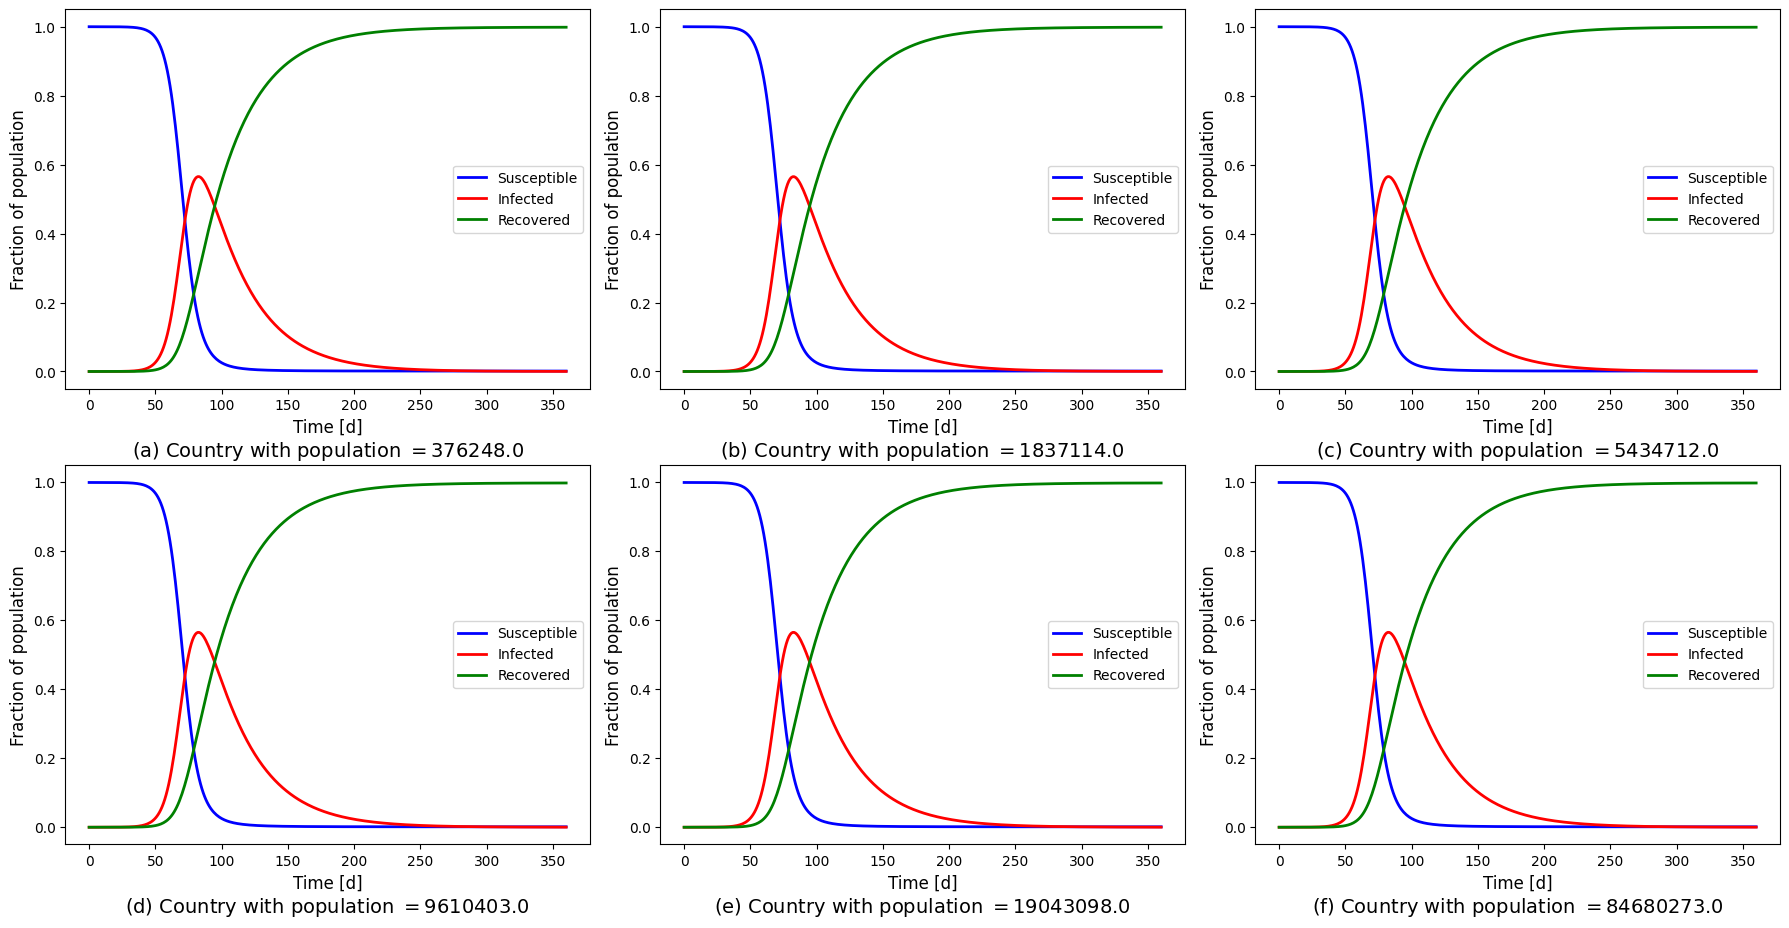

In [15]:
social_connectivity_comp(population, init_state, C,
                          t_end=360, infection_rate=beta, recovery_rate=mu)

Location : HR ; Population : 375871.752


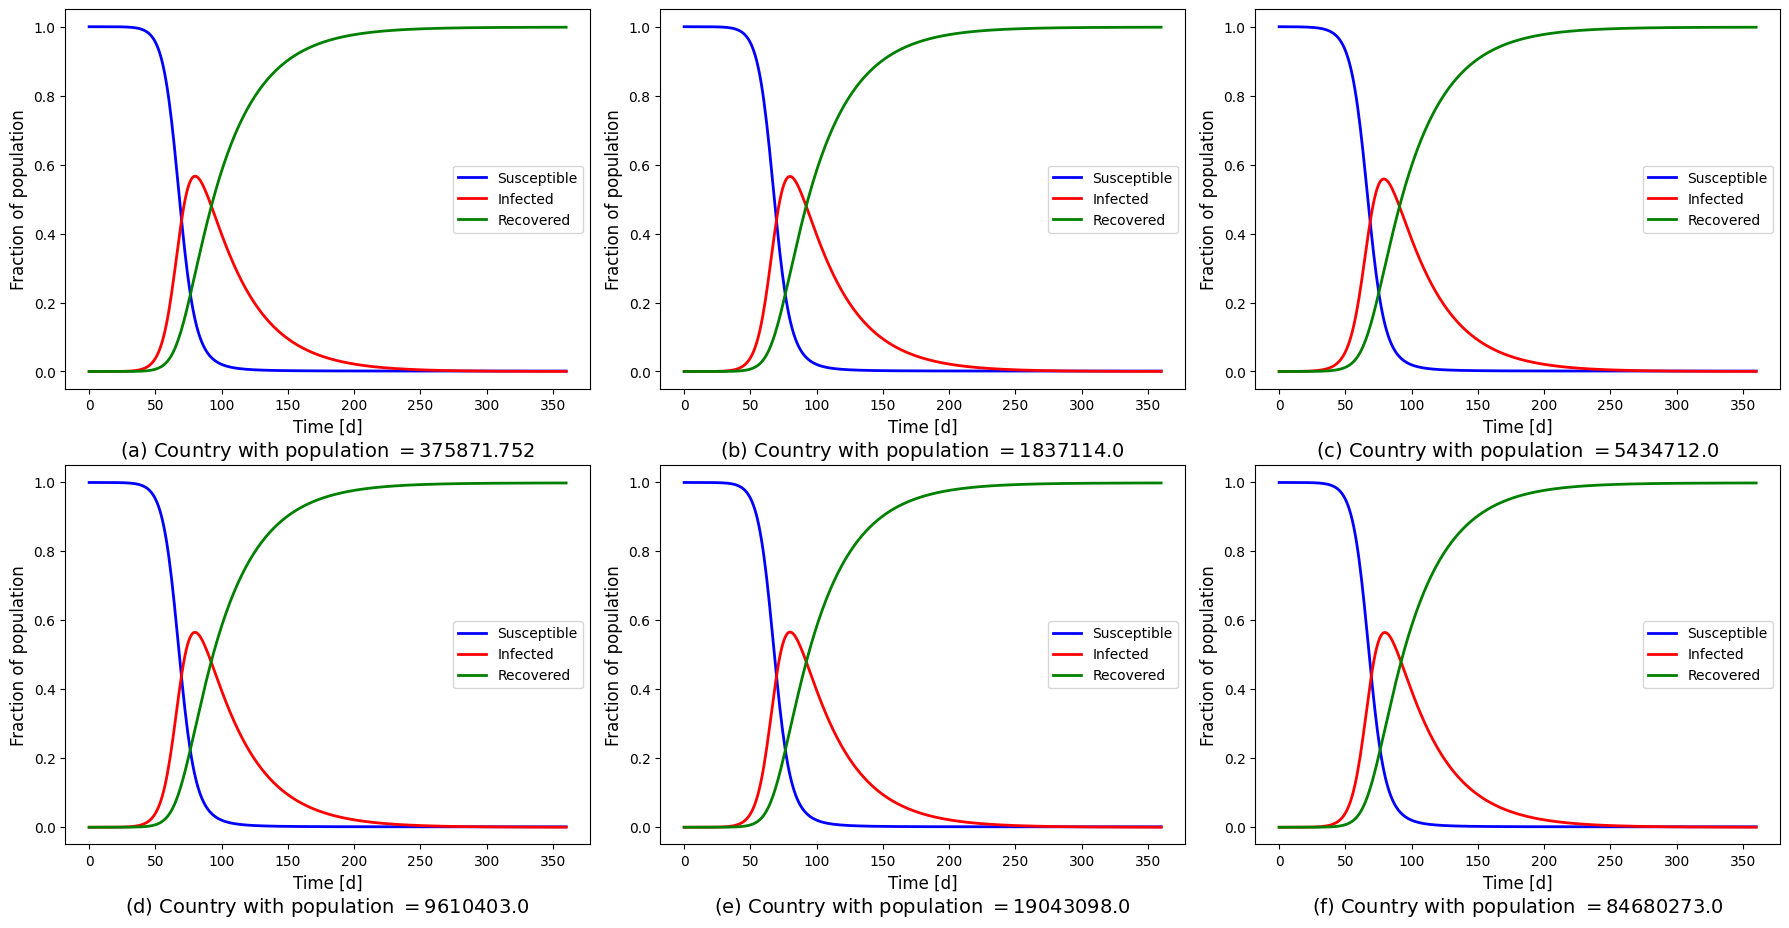

In [43]:
# Seed 0.1% infection in the lowest populated country; rest fully susceptible
S0 = population
S0[np.argmin(population)] = 0.999 * np.min(population)

I0 = np.zeros_like(population)
I0[np.argmin(population)] = 0.001 * np.min(population)

print("Location :", valid_countries[np.argmin(population)], "; Population :", np.min(population))

social_connectivity_comp(population, init_state, C,
                          t_end=360, infection_rate=beta, recovery_rate=mu)

Location : RO ; Population : 84595592.727


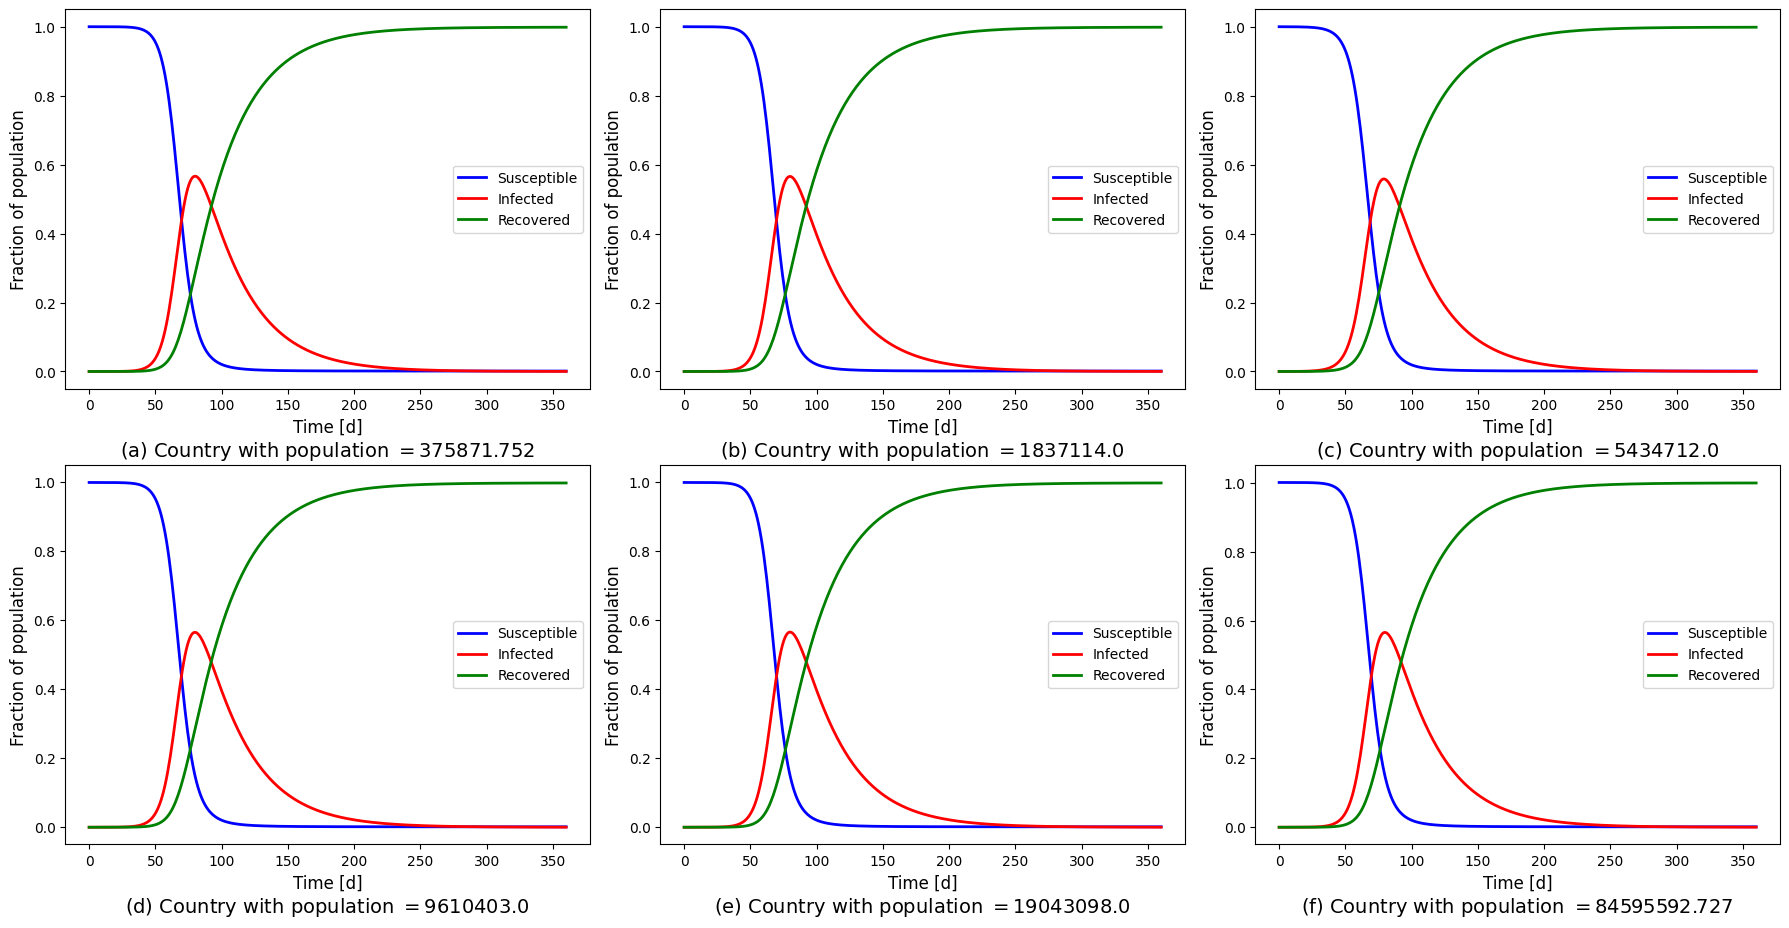

In [44]:
# Seed 0.1% infection in the highest populated country; rest fully susceptible
S0 = population
S0[np.argmax(population)] = 0.999 * np.max(population)

I0 = np.zeros_like(population)
I0[np.argmax(population)] = 0.001 * np.max(population)

print("Location :", valid_countries[np.argmax(population)], "; Population :", np.max(population))

social_connectivity_comp(population, init_state, C,
                          t_end=360, infection_rate=beta, recovery_rate=mu)

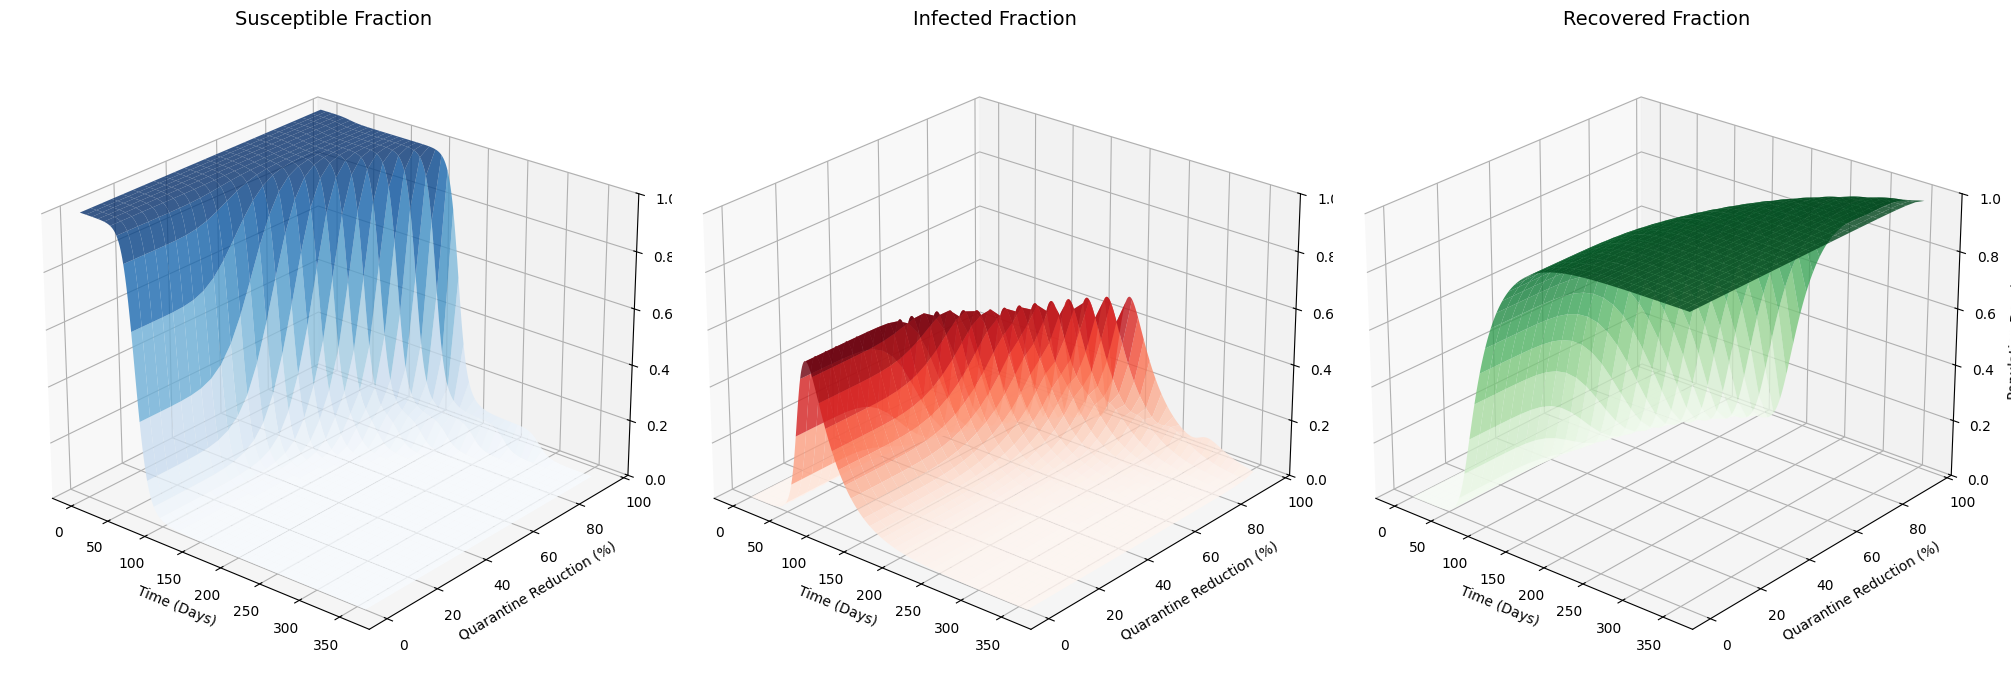

In [45]:
quarantine_plotter_3d(population, init_state, C,
                        infection_rate=beta, recovery_rate=mu, t_end=360)

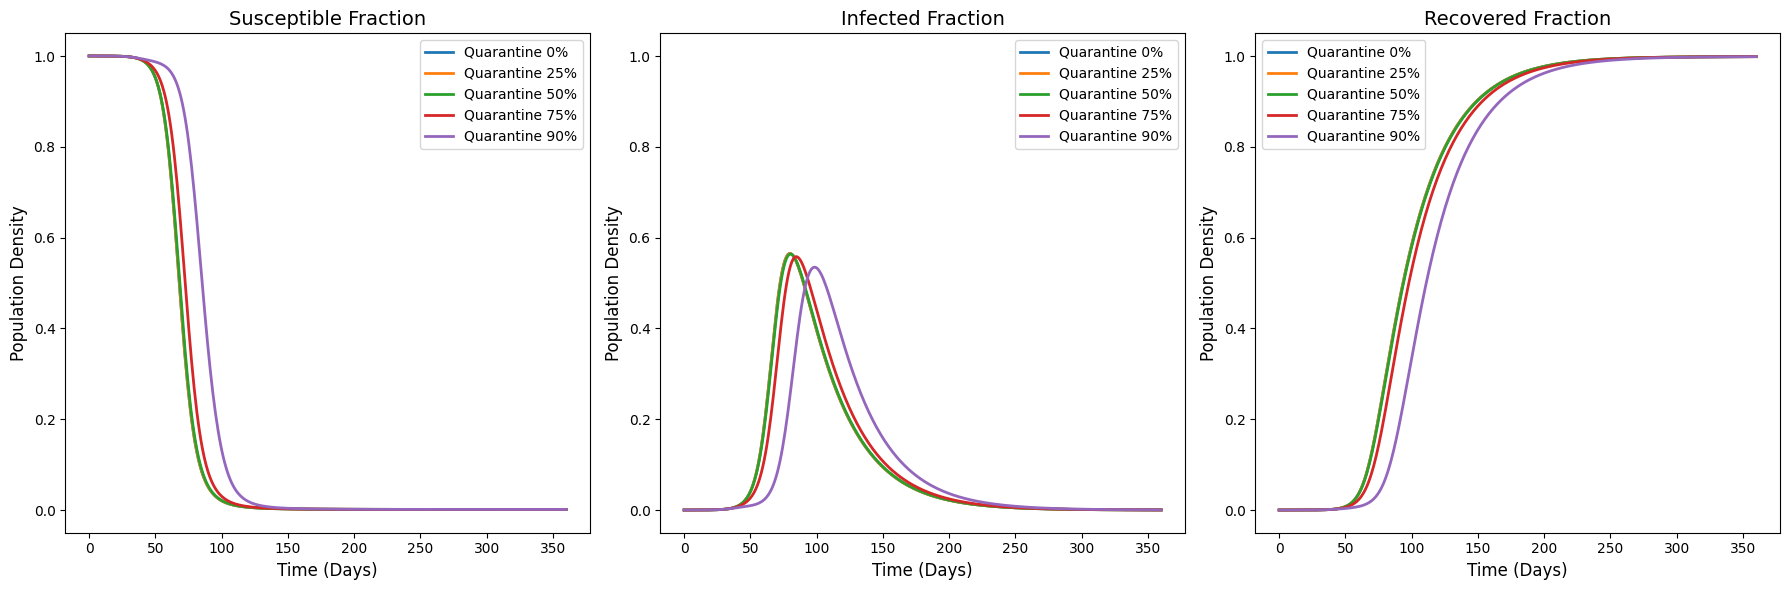

In [46]:
quarantine_plotter_2d(population, init_state, C,
                        infection_rate=beta, recovery_rate=mu, t_end=360)

Running 25 simulations. Please wait...


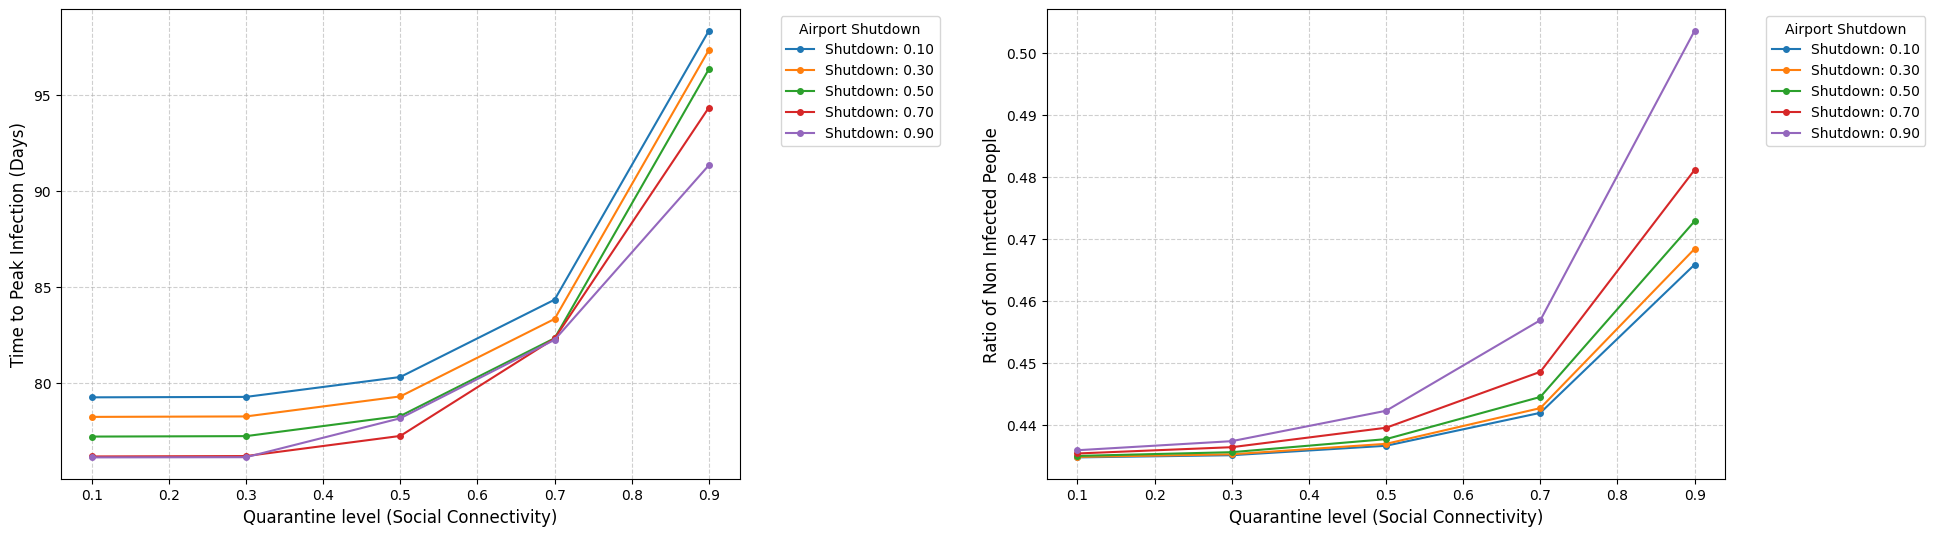

In [47]:
local_vs_global_quarantine_2d(population, init_state, C, beta, mu, 
                               t_end=360, 
                               quarantine_range=np.linspace(0.1, 0.9, 5),
                               top_nodes_under_quarantine=5,
                               social_connectivity_range=np.linspace(0.1, 0.9, 5))